In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('transaction_FM.csv')
df 

,transaction_id,persona_id,date,description,amount,category,is_labelled
0,1,P01,01/09/2023,Balance brought forward,0.00,Excluded,True
1,2,P01,01/09/2023,DIRECT DEBIT BUPA AUSTRALIA DDR ID 098647,120.90,Essential,True
2,3,P01,01/09/2023,VISA PURCHASE HENRY COFFEE FORTITUDE VLY,6.19,Non-Essential,True
3,4,P01,02/09/2023,VISA PURCHASE SUSHI HUB CBD,9.11,Non-Essential,True
4,5,P01,02/09/2023,POS CAMPOS SOUTH BRISBANE TID 957282,6.29,Non-Essential,True
...,...,...,...,...,...,...,...
33863,33864,P10,30/08/2025,CARD PURCHASE 30AUG 7-ELEVEN 8440 SANDY BAY,8.52,NaN,False
33864,33865,P10,30/08/2025,EFTPOS PURCHASE DAILY GRIND BATTERY PT TID 974982,4.82,NaN,False
33865,33866,P10,31/08/2025,POS HARRIS FARM NORTH HOBART TID 244192,128.60,NaN,False
33866,33867,P10,31/08/2025,Total debits,146702.37,NaN,False


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 33868 entries, 0 to 33867
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  33868 non-null  int64  
 1   persona_id      33868 non-null  str    
 2   date            33868 non-null  str    
 3   description     33868 non-null  str    
 4   amount          33868 non-null  float64
 5   category        5000 non-null   str    
 6   is_labelled     33868 non-null  bool   
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 1.6 MB


,transaction_id,amount
count,33868.000000,33868.000000
mean,16934.500000,4.362917
std,9776.993795,3424.328476
min,1.000000,-176432.480000
25%,8467.750000,5.300000
50%,16934.500000,6.400000
75%,25401.250000,18.000000
max,33868.000000,163813.490000


In [4]:
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df['amount'] = df['amount'].astype('float64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33868 entries, 0 to 33867
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  33868 non-null  int64  
 1   persona_id      33868 non-null  str    
 2   date            33868 non-null  str    
 3   description     33868 non-null  str    
 4   amount          33868 non-null  float64
 5   category        5000 non-null   str    
 6   is_labelled     33868 non-null  bool   
dtypes: bool(1), float64(1), int64(1), str(4)
memory usage: 1.6 MB


In [5]:
df['description'].value_counts()
df['description'].info()

<class 'pandas.Series'>
RangeIndex: 33868 entries, 0 to 33867
Series name: description
Non-Null Count  Dtype
--------------  -----
33868 non-null  str  
dtypes: str(1)
memory usage: 264.7 KB


In [6]:
result = df['description'].value_counts()
result = df['description'].value_counts().to_frame().head(30)
result 


,count
description,
APPLE.COM/BILL AUS,471
APPLE.COM/BILL,452
UBER *TRIP HELP.UBER.COM NLD,235
NBK TRSF FROM SAVER,165
UBER *EATS HELP.UBER.COM NLD,152
SPOTIFY P0652 STOCKHOLM,149
APPLE.COM/BILL ICLD 50GB,149
NETFLIX.COM AMSTERDAM NLD,146
NETBANK TRANSFER FROM SAVER,144


In [7]:
def nettoyage_avance(texte):
    if not isinstance(texte, str):
    
     if "APPLE.COM" in texte: return "APPLE SERVICES"
    if "UBER *EATS" in texte: return "UBER EATS"
    if "7-ELEVEN" in texte: return "7-ELEVEN"
    if "UBER *TRIP" in texte: return "UBER TRIP"


In [8]:
import re
def nettoyage_avance(texte):
    if not isinstance(texte, str):
        return texte
    
    prefixes = [r"EFTPOS PURCHASE ", r"POS ", r"VISA PURCHASE ", r"CARD PURCHASE ", r"DIRECT DEBIT", r"CBD", r"CARD"]
    for p in prefixes:
        texte = re.sub(p, "", texte)

    texte = texte.upper()
    
    texte = re.sub(r'TID\s?\d+', '', texte)
    
    texte = re.sub(r'\d{1,2}[A-Z]{3}', '', texte)
    
    if "APPLE.COM" in texte: return "APPLE SERVICES"
    if "UBER *EATS" in texte: return "UBER EATS"
    if "7-ELEVEN" in texte: return "7-ELEVEN"
    if "UBER *TRIP" in texte: return "UBER TRIP"

    if "COFFEE" in texte or "ST DREUX" in texte or "CAMPOS" in texte or "": 
        return "COFFEE SHOP"
    
    if "TRSF FROM SAVER" in texte or "TRANSFER FROM SAVER" in texte: 
        return "BANK TRANSFER FROM SAVER"
    if "TRSF TO SAVER" in texte or "TRANSFER TO SAVER" in texte: 
        return "BANK TRANSFER TO SAVER"
    if "NETFLIX" in texte: return "NETFLIX"
    if "SPOTIFY" in texte: return "SPOTIFY"


    if "DOORDASH" in texte: return "RESTAURANT"
    if "PITA PIT" in texte: return "RESTAURANT"
    if "MAD MEX" in texte: return "RESTAURANT"
    if "HOKKAIDO RAMEN" in texte: return "RESTAURANT"
    if "ROLLD" in texte: return "RESTAURANT"
    if "SUSHI HUB" in texte: return "RESTAURANT"
    if "BANH MI" in texte: return "RESTAURANT"
    if "GUZMAN Y GOMEZ" in texte: return "RESTAURANT"
    if "TANPOPO JAPANESE" in texte: return "RESTAURANT"
    if "MENULOG" in texte: return "RESTAURANT"

    if "COLES" in texte: return "SUPERMARKET"
    if "WOOLWORTHS" in texte: return "SUPERMARKET"
    if "ALDI" in texte: return "SUPERMARKET"
    if "IGA" in texte: return "SUPERMARKET"
    if "HARRIS FARM" in texte: return "SUPERMARKET"

  
    if "PRICELINE" in texte or "CHEMIST WAREHOUSE" in texte:
        return "HEALTH & PHARMACY"
    


    if "BUPA" in texte: return "HEALTH INSURANCE (BUPA)"
    if "OPTUS" in texte: return "TELECOM (OPTUS)"
    if "METROCARD" in texte: return "TRANSPORT (METROCARD)"
   
    cafes = ["DAILY GRIND", "SINGLE O", "CAMPOS", "COFFEE HERO", "RUBY COFFEE", "HENRY COFFEE", "ST DREUX", "MECCA"]
    if any(c in texte for c in cafes) or "COFFEE" in texte:
        return "COFFEE SHOP"

    for loc in ["CBD", "NORWOOD", "GLENELG", "PROSPECT", "NORTH", "HOBART", "SANDY BAY", "BATTERY PT"]:
        texte = texte.replace(loc, "")
    if "BOLT" in texte: return "BOLT"

    texte = re.sub(r'\s+', ' ', texte).strip()
    
    return texte
df['description_clean'] = df['description'].apply(nettoyage_avance)

In [9]:
def nettoyage(texte):

    return re.sub(pattern=r"HELP\.UBER\.COM", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [10]:
def nettoyage(texte):

    return re.sub(pattern=r"NLD", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [11]:
def nettoyage(texte):

    return re.sub(pattern=r"APPLE PRODUCT", repl="APPLE SERVICES", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [12]:
def nettoyage(texte):

    return re.sub(pattern=r"APPLE./BILL", repl="APPLE SERVICES", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [13]:
def nettoyage(texte):

    return re.sub(pattern=r"APPLE SERVICES ICLD 50GB", repl="APPLE ICLOUD SERVICES", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [14]:
def nettoyage(texte):

    return re.sub(pattern=r"VISA PURCHASE", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [15]:
def nettoyage(texte):

    return re.sub(pattern=r"SINGLE O CBD", repl="COFFEE SHOP", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [16]:
def nettoyage(texte):

    return re.sub(pattern=r"DAILY GRIND CBD", repl="COFFEE SHOP", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [17]:
def nettoyage(texte):

    return re.sub(pattern=r"VISA PURCHASE", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [18]:
def nettoyage(texte):

    return re.sub(pattern=r"ADELAIDE", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [19]:
def nettoyage(texte):

    return re.sub(pattern=r"VISA PURCHASE", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [20]:
def nettoyage(texte):

    return re.sub(pattern=r"AUSTRALIA", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)

In [21]:
def nettoyage(texte):

    return re.sub(pattern=r"AUSTRALIA", repl="", string=texte)
df['description_clean'] = df['description_clean'].apply(nettoyage)


In [22]:
result = df['description_clean'].value_counts()
result = df['description_clean'].value_counts().to_frame().head(30)
result 

,count
description_clean,
COFFEE SHOP,12360
RESTAURANT,7420
7-ELEVEN,2975
SUPERMARKET,1245
APPLE SERVICES,1072
CAM,643
HEALTH & PHARMACY,482
UBER TRIP,456
UBER EATS,418


In [31]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split


df = pd.read_csv('transaction_FM.csv')


def clean_engine(texte):
    if not isinstance(texte, str): 
        return ""

    prefixes = [r"EFTPOS PURCHASE ", r"POS ", r"VISA PURCHASE ", r"CARD PURCHASE ", r"DIRECT DEBIT", r"CBD", r"CARD"]
    for p in prefixes:
        texte = re.sub(p, "", texte)

    texte = texte.upper()
    texte = re.sub(r'TID\s?\d+', '', texte)
    texte = re.sub(r'\d{1,2}[A-Z]{3}', '', texte)
    
    if "APPLE.COM" in texte: return "APPLE SERVICES"
    if "UBER *EATS" in texte: return "UBER EATS"
    if "7-ELEVEN" in texte: return "7-ELEVEN"
    if "UBER *TRIP" in texte: return "UBER TRIP"

    if "COFFEE" in texte or "ST DREUX" in texte or "CAMPOS" in texte: 
        return "COFFEE SHOP"
    
    if "TRSF FROM SAVER" in texte or "TRANSFER FROM SAVER" in texte: 
        return "BANK TRANSFER FROM SAVER"
    if "TRSF TO SAVER" in texte or "TRANSFER TO SAVER" in texte: 
        return "BANK TRANSFER TO SAVER"
    if "NETFLIX" in texte: return "NETFLIX"
    if "SPOTIFY" in texte: return "SPOTIFY"

    # Optimisation : regroupement des restaurants
    restos = ["DOORDASH", "PITA PIT", "MAD MEX", "HOKKAIDO RAMEN", "ROLLD", "SUSHI HUB", "BANH MI", "GUZMAN Y GOMEZ", "TANPOPO JAPANESE", "MENULOG"]
    if any(r in texte for r in restos): return "RESTAURANT"

    # Optimisation : regroupement des supermarchés
    supers = ["COLES", "WOOLWORTHS", "ALDI", "IGA", "HARRIS FARM"]
    if any(s in texte for s in supers): return "SUPERMARKET"

    if "PRICELINE" in texte or "CHEMIST WAREHOUSE" in texte:
        return "HEALTH & PHARMACY"

    if "BUPA" in texte: return "HEALTH INSURANCE (BUPA)"
    if "OPTUS" in texte: return "TELECOM (OPTUS)"
    if "METROCARD" in texte: return "TRANSPORT (METROCARD)"
   
    cafes = ["DAILY GRIND", "SINGLE O", "CAMPOS", "COFFEE HERO", "RUBY COFFEE", "HENRY COFFEE", "ST DREUX", "MECCA"]
    if any(c in texte for c in cafes) or "COFFEE" in texte:
        return "COFFEE SHOP"

    for loc in ["CBD", "NORWOOD", "GLENELG", "PROSPECT", "NORTH", "HOBART", "SANDY BAY", "BATTERY PT"]:
        texte = texte.replace(loc, "")
        
    if "BOLT" in texte: return "BOLT"

    
    return re.sub(r'\s+', ' ', texte).strip()


df['description_clean'] = df['description'].apply(clean_engine)


df = df.dropna(subset=['category', 'description_clean'])


X = df['description_clean']
y = df['category']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("GOOD")

GOOD


<function classification_report at 0x00000204A758F1C0> ['Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Essential' 'Non-Essential'
 'Non-Essential' 'Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Essential'
 'Non-Essential' 'Non-Essential' 'Excluded' 'Non-Essential'
 'Non-Essential' 'Essential' 'Non-Essential' 'Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Essential' 'Essential'
 'Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Essential'
 'Non-Essential' 'Non-Essential' 'Non-Essential' 'Non-Essential'
 'Non-Essential' 'Non-Essential'

<Figure size 120x100 with 0 Axes>

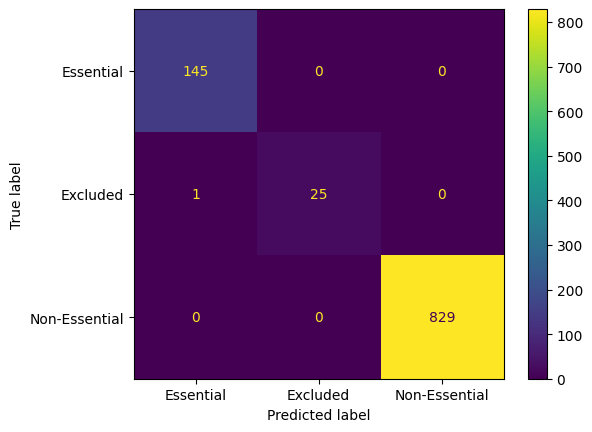

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline


model_pipeline = Pipeline ([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB()),
])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

print(classification_report, y_pred, y_test)

plt.figure(figsize=(12,10), dpi=10)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


In [75]:
import sqlite3
from sqlalchemy import create_engine

engine = create_engine('sqlite:///ma_finance.db')


df.to_sql('transactions_clean', con=engine, if_exists='replace', index=False)

print("Good, the data are added to your SQL.")


Good, the data are added to your SQL.
